In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score



## ETL


In [79]:
file_path = "./Datasets/healthData.csv"
try:
    df = pd.read_csv(file_path, na_values=["N/A"])
except FileNotFoundError:
    print("File not found.")
    df = None
    
data = df.copy()

In [80]:
# performing ETL (Extract, Transform, Load) on the dataset
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)

    print("First 5 rows of the dataset:\n", data.head())

    print("Shape of the dataset:", data.shape)
    
    print("Dataset Info:",data.info())
    
    print("\nMissing Values:",data.isnull().sum())

    print("\nStatistical Summary:\n",data.describe())

    print("\nDuplicate Rows:",data.duplicated().sum())

    print("\nUnique Values per Column:\n",data.nunique())
    
    return data

In [81]:
data = load_and_preprocess_data(file_path)

First 5 rows of the dataset:
       id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       0  
2       1  
3       1  
4       1  
Shape of the dataset: (511

## EDA


In [82]:
data=data.drop(columns=['id'])

In [83]:
numeric_cols = data.select_dtypes(include=np.number).columns
categorical_cols = data.select_dtypes(include=['object', 'str']).columns

In [84]:
numeric_cols

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke'],
      dtype='str')

In [85]:
categorical_cols

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')

In [86]:
for col in data.columns:
    print(col, data[col].unique())

gender <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
age [6.70e+01 6.10e+01 8.00e+01 4.90e+01 7.90e+01 8.10e+01 7.40e+01 6.90e+01
 5.90e+01 7.80e+01 5.40e+01 5.00e+01 6.40e+01 7.50e+01 6.00e+01 5.70e+01
 7.10e+01 5.20e+01 8.20e+01 6.50e+01 5.80e+01 4.20e+01 4.80e+01 7.20e+01
 6.30e+01 7.60e+01 3.90e+01 7.70e+01 7.30e+01 5.60e+01 4.50e+01 7.00e+01
 6.60e+01 5.10e+01 4.30e+01 6.80e+01 4.70e+01 5.30e+01 3.80e+01 5.50e+01
 1.32e+00 4.60e+01 3.20e+01 1.40e+01 3.00e+00 8.00e+00 3.70e+01 4.00e+01
 3.50e+01 2.00e+01 4.40e+01 2.50e+01 2.70e+01 2.30e+01 1.70e+01 1.30e+01
 4.00e+00 1.60e+01 2.20e+01 3.00e+01 2.90e+01 1.10e+01 2.10e+01 1.80e+01
 3.30e+01 2.40e+01 3.40e+01 3.60e+01 6.40e-01 4.10e+01 8.80e-01 5.00e+00
 2.60e+01 3.10e+01 7.00e+00 1.20e+01 6.20e+01 2.00e+00 9.00e+00 1.50e+01
 2.80e+01 1.00e+01 1.80e+00 3.20e-01 1.08e+00 1.90e+01 6.00e+00 1.16e+00
 1.00e+00 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+00 7.20e-01 1.88e+00
 1.24e+00 8.00e-01 4.00e-01 8.00e-02 1.48e+00 5.6

In [87]:
binary_map = {
    "ever_married": {"No": 0, "Yes": 1},
    "Residence_type": {"Rural": 0, "Urban": 1}
}

In [88]:
for col, mapping in binary_map.items():
    data[col] = data[col].map(mapping)

In [89]:
data['gender']=data['gender'].map({"Female": 0, "Male": 1, "Other": 2})

In [90]:
data['bmi']=data['bmi'].fillna(data['bmi'].mean())

In [91]:
data['smoking_status'] = data['smoking_status'].replace("Unknown", data['smoking_status'].mode()[0])

In [92]:
# mapping for work_type and smoking_status
work_type_mapping = {
    "Private": 0,
    "Self-employed": 1,
    "Govt_job": 2,
    "children": 3,
    "Never_worked": 4
}

smoking_status_mapping = {
    "never smoked": 0,
    "formerly smoked": 1,
    "smokes": 2
}
data['work_type'] = data['work_type'].map(work_type_mapping)
data['smoking_status'] = data['smoking_status'].map(smoking_status_mapping)



In [93]:
data.isnull().sum().sum()

np.int64(0)

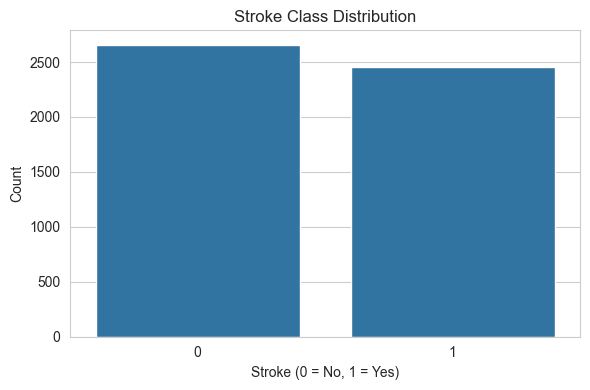

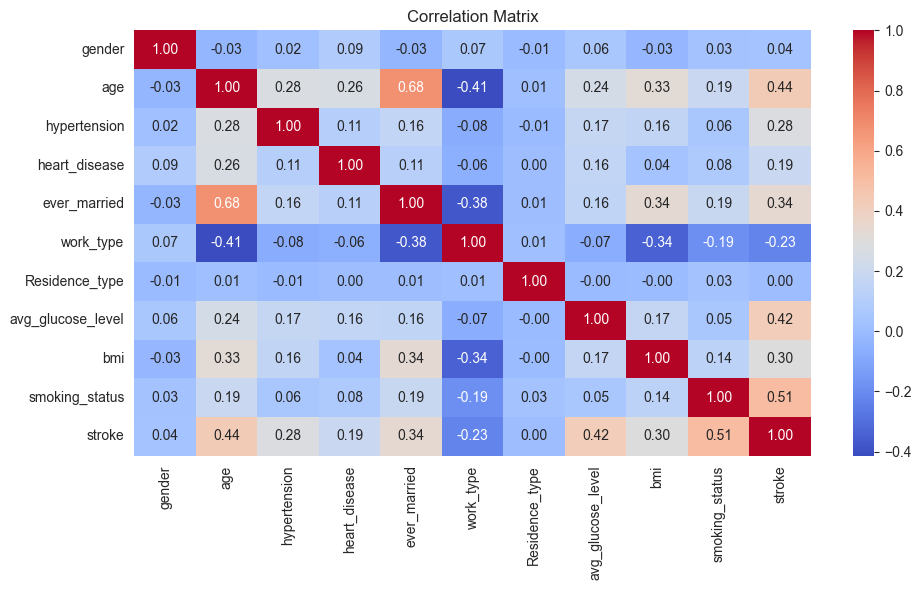

In [94]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="stroke")
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

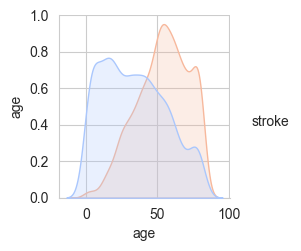

In [95]:
sns.pairplot(data[['age', 'stroke']], hue='stroke', palette='coolwarm', diag_kind='kde') 

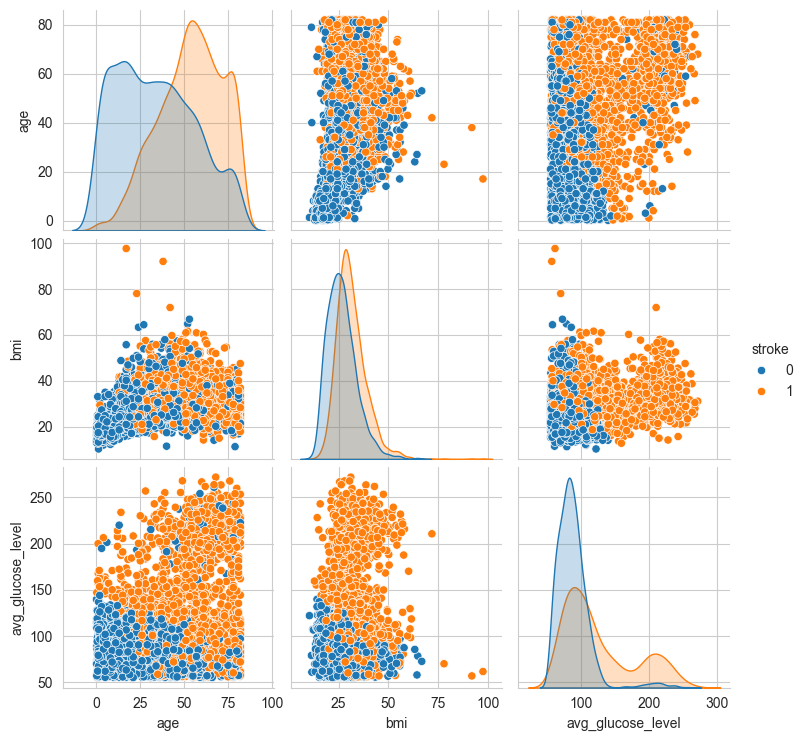

In [113]:
sns.pairplot(
    df[['age','bmi','avg_glucose_level','stroke']],
    hue='stroke'
)
plt.show()

## Modeling


In [97]:
# Initialize metrics DataFrame to collect evaluation metrics for each model
import pandas as pd
metrics_columns = ['Model','Accuracy','ROC_AUC','Precision','Recall','F1']
metrics_df = pd.DataFrame(columns=metrics_columns)
metrics_df

,Model,Accuracy,ROC_AUC,Precision,Recall,F1


In [98]:
X = data.drop("stroke", axis=1)
y = data["stroke"]

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [100]:
# lr_model = LinearRegression()
# lr_model.fit(X_train, y_train)

# y_pred_lr = lr_model.predict(X_test)
# y_pred_lr_class = np.where(y_pred_lr >= 0.5, 1, 0)

# print("Linear Regression")
# print("MSE:", mean_squared_error(y_test, y_pred_lr))
# print("MAE:", mean_absolute_error(y_test, y_pred_lr))
# print("R2:", r2_score(y_test, y_pred_lr))
# print("Accuracy:", accuracy_score(y_test, y_pred_lr_class))

# # metrics
# acc = accuracy_score(y_test, y_pred_lr_class)
# try:
#     roc = roc_auc_score(y_test, y_pred_lr)
# except Exception:
#     roc = float('nan')
# prec = precision_score(y_test, y_pred_lr_class, zero_division=0)
# rec = recall_score(y_test, y_pred_lr_class, zero_division=0)
# f1 = f1_score(y_test, y_pred_lr_class, zero_division=0)

# metrics_df.loc[len(metrics_df)] = ['Linear Regression', acc, roc, prec, rec, f1]
# print(metrics_df.tail(1))


In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# metrics
acc = accuracy_score(y_test, y_pred_lr)
roc = roc_auc_score(y_test, y_prob_lr)
prec = precision_score(y_test, y_pred_lr, zero_division=0)
rec = recall_score(y_test, y_pred_lr, zero_division=0)
f1 = f1_score(y_test, y_pred_lr, zero_division=0)

metrics_df.loc[len(metrics_df)] = ['Logistic Regression', acc, roc, prec, rec, f1]
print(metrics_df.tail(1))


Logistic Regression
Accuracy: 0.8884540117416829
ROC-AUC: 0.9506445587428707
[[493  38]
 [ 76 415]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       531
           1       0.92      0.85      0.88       491

    accuracy                           0.89      1022
   macro avg       0.89      0.89      0.89      1022
weighted avg       0.89      0.89      0.89      1022

                 Model  Accuracy   ROC_AUC  Precision    Recall        F1
0  Logistic Regression  0.888454  0.950645   0.916115  0.845214  0.879237


In [102]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# metrics
acc = accuracy_score(y_test, y_pred_dt)
roc = roc_auc_score(y_test, y_prob_dt)
prec = precision_score(y_test, y_pred_dt, zero_division=0)
rec = recall_score(y_test, y_pred_dt, zero_division=0)
f1 = f1_score(y_test, y_pred_dt, zero_division=0)

metrics_df.loc[len(metrics_df)] = ['Decision Tree', acc, roc, prec, rec, f1]
print(metrics_df.tail(1))


Decision Tree
Accuracy: 0.9549902152641878
ROC-AUC: 0.980567349772362
[[511  20]
 [ 26 465]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       531
           1       0.96      0.95      0.95       491

    accuracy                           0.95      1022
   macro avg       0.96      0.95      0.95      1022
weighted avg       0.96      0.95      0.95      1022

           Model  Accuracy   ROC_AUC  Precision    Recall        F1
1  Decision Tree   0.95499  0.980567   0.958763  0.947047  0.952869


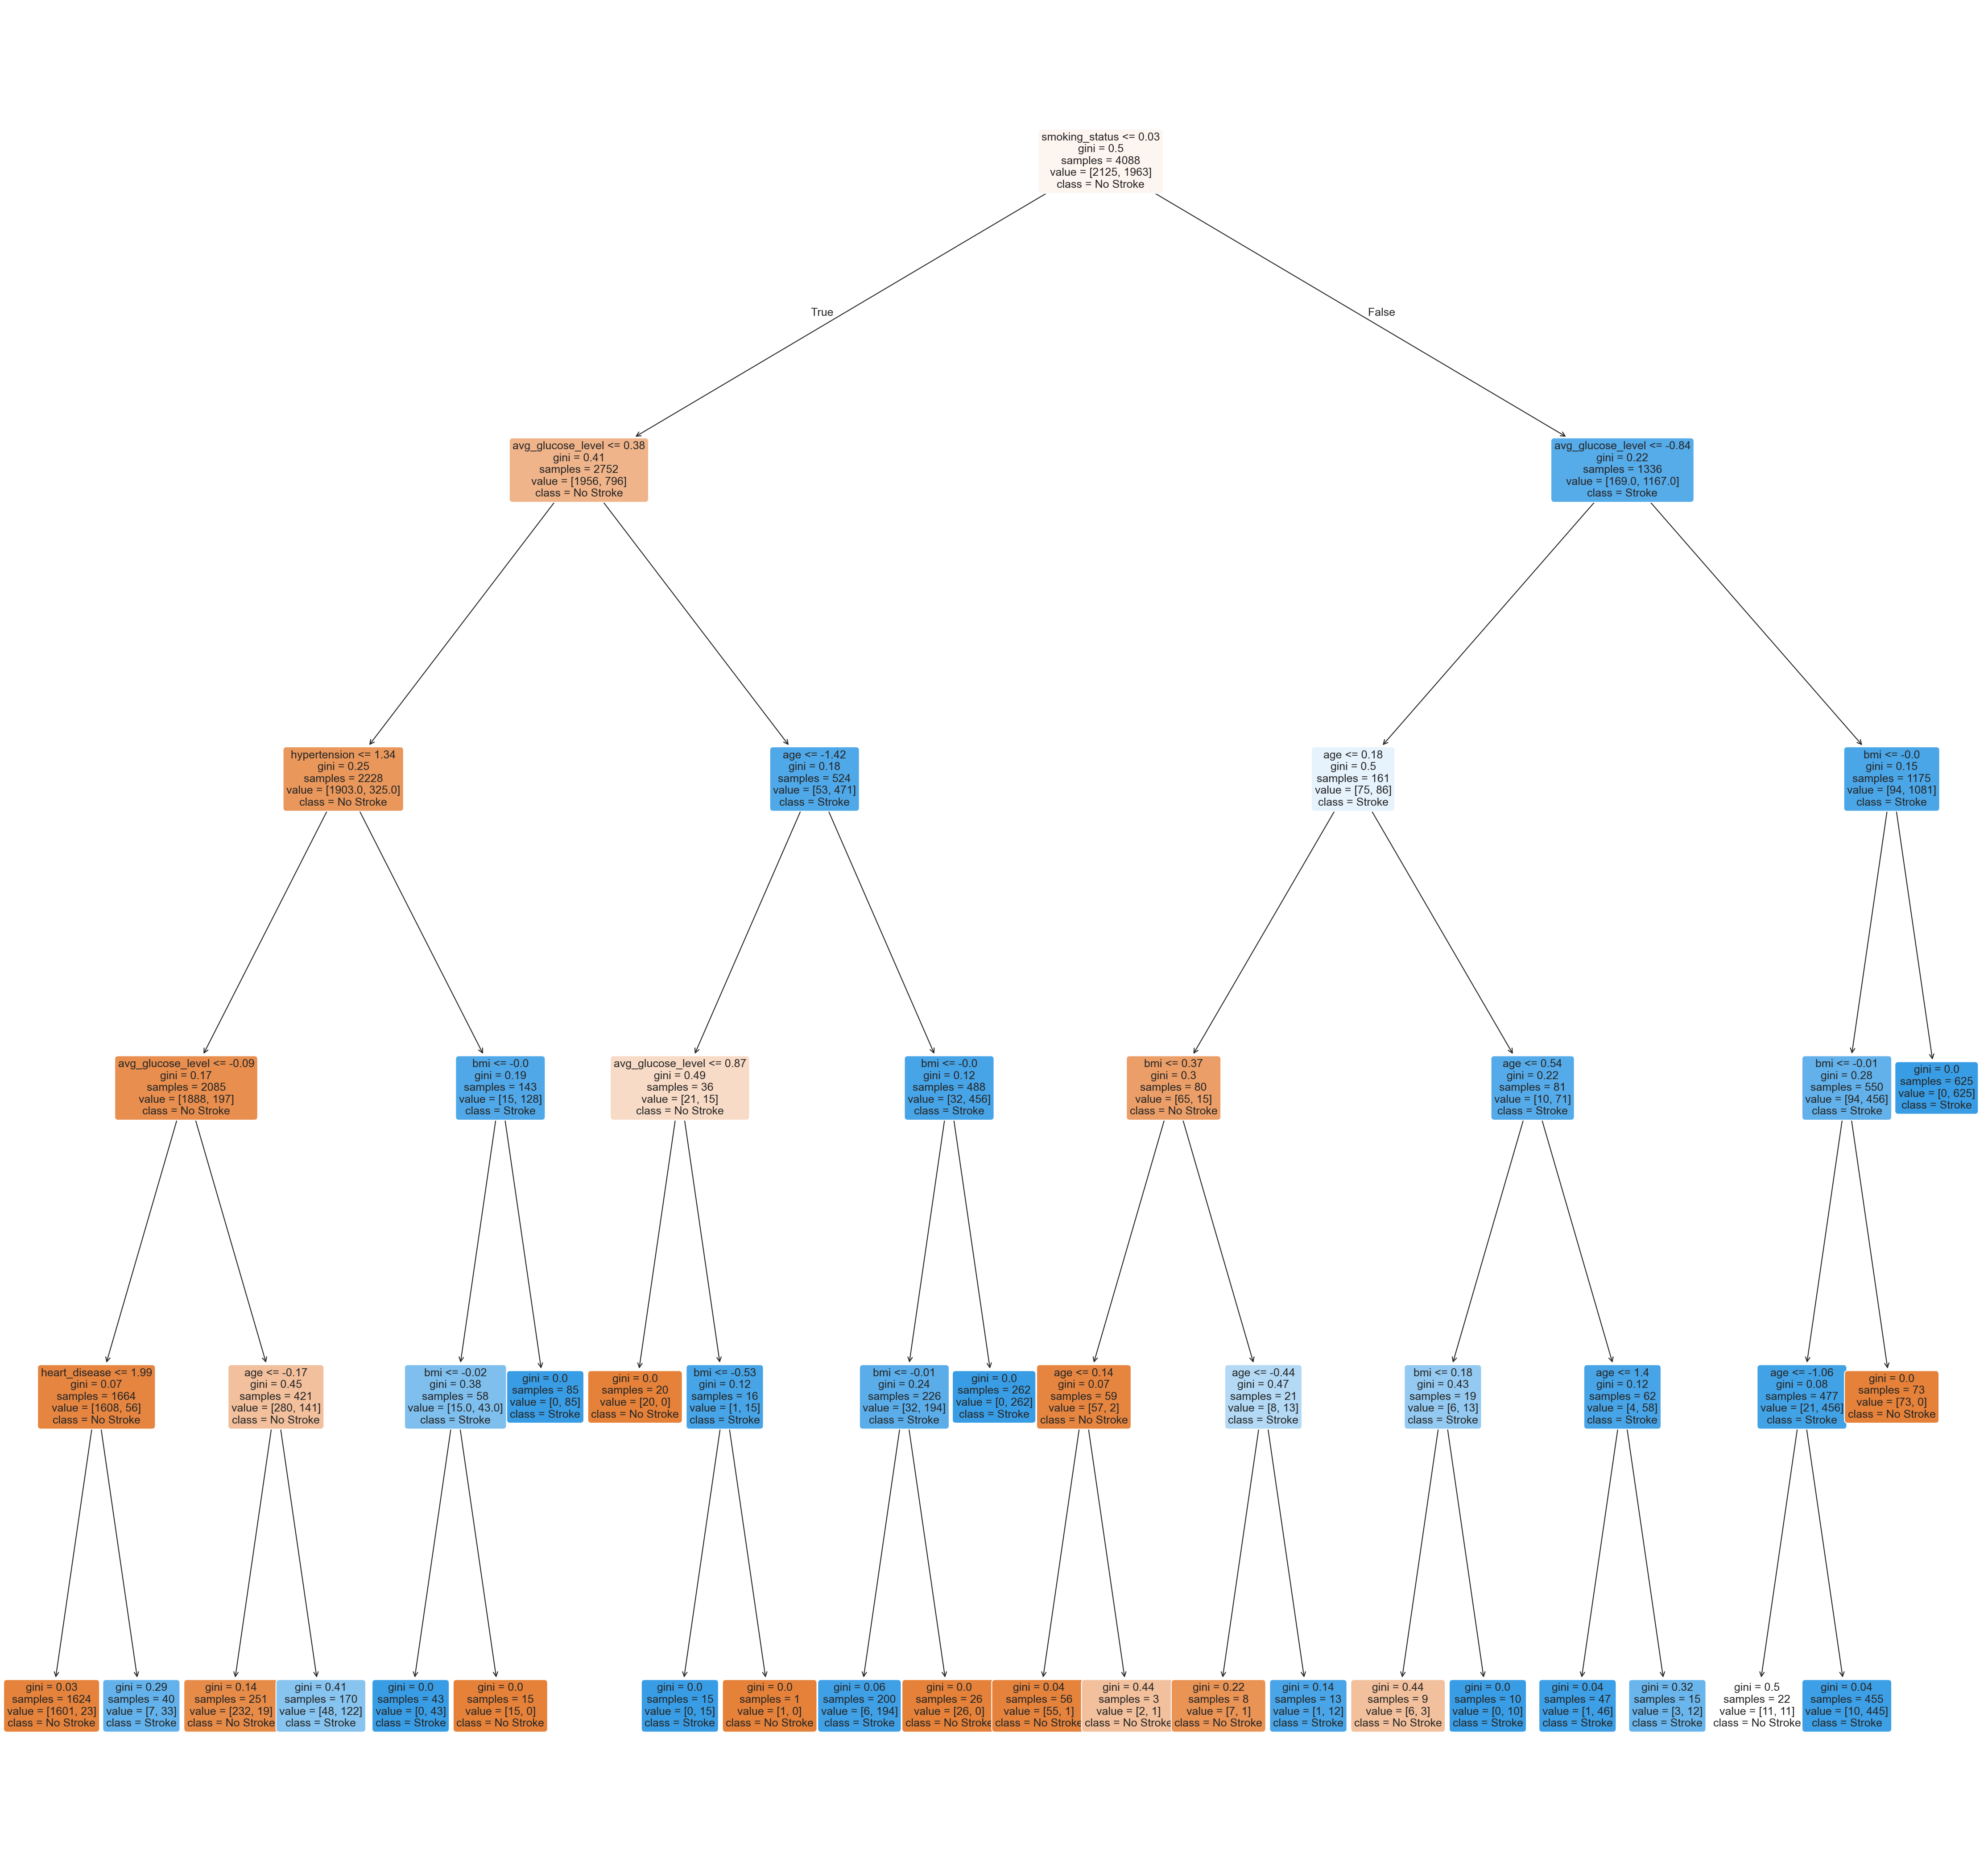

In [103]:
plt.figure(figsize=(30,28), dpi=150)
plot_tree(dt, filled=True, feature_names=X.columns, class_names=["No Stroke", "Stroke"],
          rounded=True, label='all', precision=2, fontsize=12)
plt.tight_layout()
plt.show()

In [104]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# metrics
acc = accuracy_score(y_test, y_pred_rf)
roc = roc_auc_score(y_test, y_prob_rf)
prec = precision_score(y_test, y_pred_rf, zero_division=0)
rec = recall_score(y_test, y_pred_rf, zero_division=0)
f1 = f1_score(y_test, y_pred_rf, zero_division=0)

metrics_df.loc[len(metrics_df)] = ['Random Forest', acc, roc, prec, rec, f1]
print(metrics_df.tail(1))


Random Forest
Accuracy: 0.9833659491193738
ROC-AUC: 0.9987400324484794
[[522   9]
 [  8 483]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       531
           1       0.98      0.98      0.98       491

    accuracy                           0.98      1022
   macro avg       0.98      0.98      0.98      1022
weighted avg       0.98      0.98      0.98      1022

           Model  Accuracy  ROC_AUC  Precision    Recall        F1
2  Random Forest  0.983366  0.99874   0.981707  0.983707  0.982706


Text(0.5, 1.0, 'Feature Importance from Random Forest')

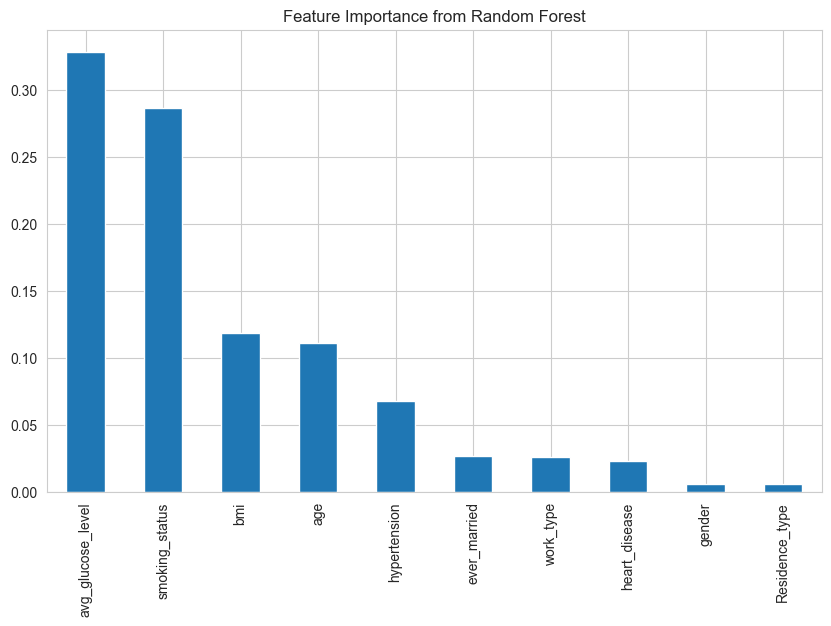

In [105]:
# feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importance from Random Forest")

In [106]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

# metrics
acc = accuracy_score(y_test, y_pred_knn)
roc = roc_auc_score(y_test, y_prob_knn)
prec = precision_score(y_test, y_pred_knn, zero_division=0)
rec = recall_score(y_test, y_pred_knn, zero_division=0)
f1 = f1_score(y_test, y_pred_knn, zero_division=0)

metrics_df.loc[len(metrics_df)] = ['KNN', acc, roc, prec, rec, f1]
print(metrics_df.tail(1))


KNN
Accuracy: 0.910958904109589
ROC-AUC: 0.9595218643684245
[[490  41]
 [ 50 441]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       531
           1       0.91      0.90      0.91       491

    accuracy                           0.91      1022
   macro avg       0.91      0.91      0.91      1022
weighted avg       0.91      0.91      0.91      1022

  Model  Accuracy   ROC_AUC  Precision    Recall        F1
3   KNN  0.910959  0.959522   0.914938  0.898167  0.906475


<Figure size 1400x800 with 0 Axes>

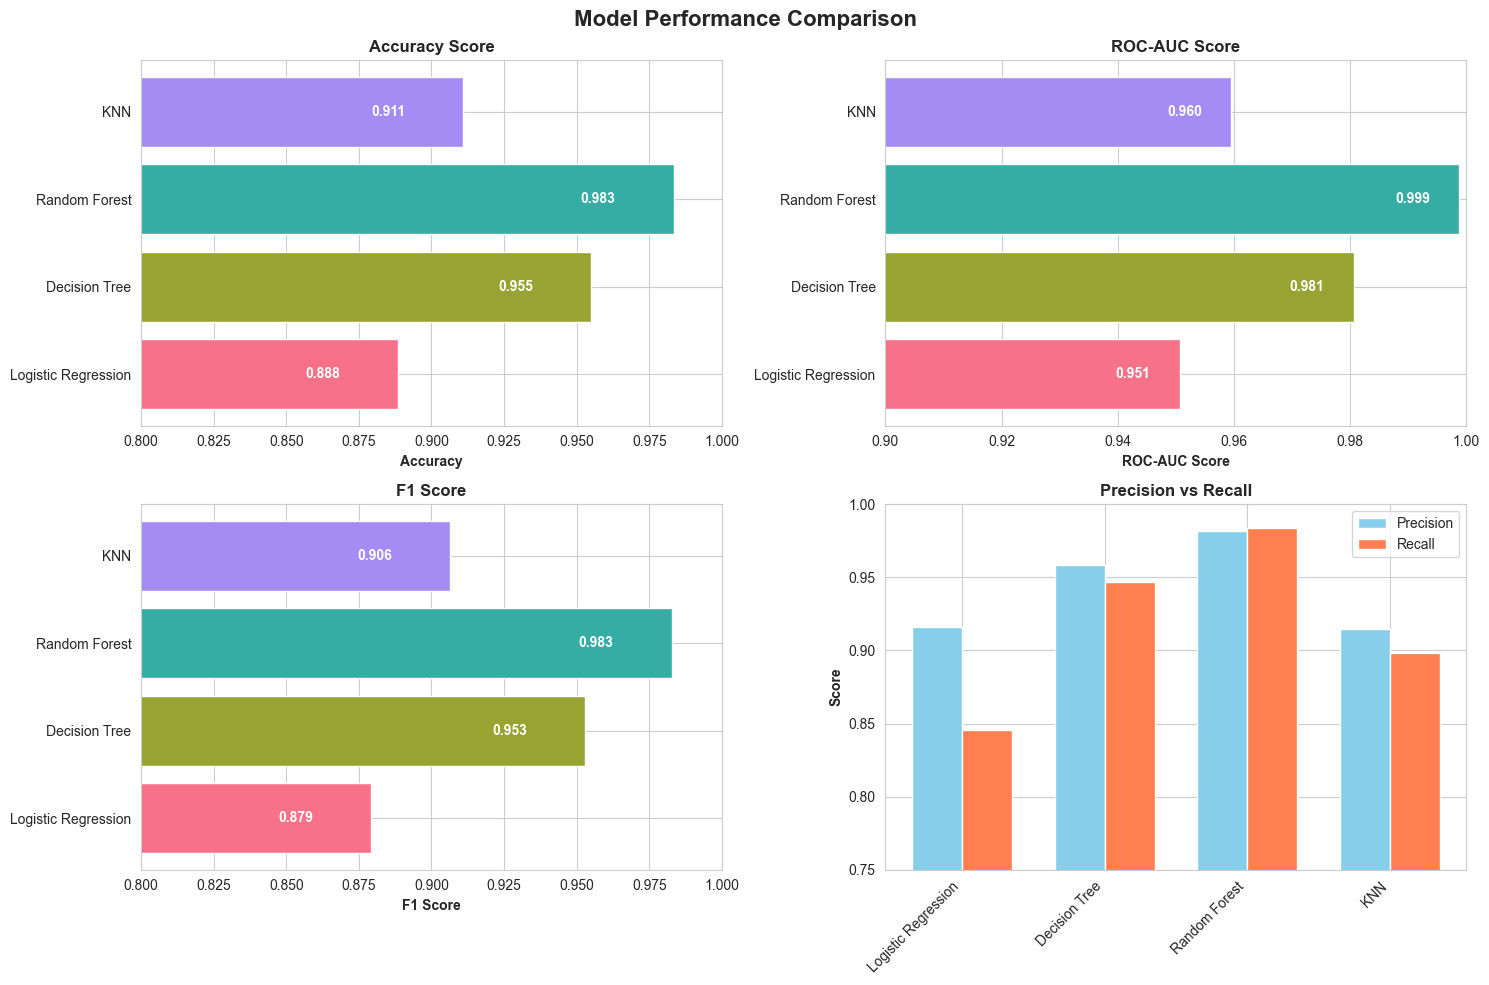

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score

sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Accuracy Comparison
ax1 = axes[0, 0]
models = metrics_df['Model']
accuracy = metrics_df['Accuracy']
colors = sns.color_palette("husl", len(models))
bars1 = ax1.barh(models, accuracy, color=colors)
ax1.set_xlabel('Accuracy', fontweight='bold')
ax1.set_title('Accuracy Score', fontweight='bold')
ax1.set_xlim([0.8, 1.0])
for i, v in enumerate(accuracy):
    ax1.text(v - 0.02, i, f'{v:.3f}', va='center', ha='right', fontweight='bold', color='white')

# ROC-AUC Comparison
ax2 = axes[0, 1]
roc_auc = metrics_df['ROC_AUC']
bars2 = ax2.barh(models, roc_auc, color=colors)
ax2.set_xlabel('ROC-AUC Score', fontweight='bold')
ax2.set_title('ROC-AUC Score', fontweight='bold')
ax2.set_xlim([0.9, 1.0])
for i, v in enumerate(roc_auc):
    if not pd.isna(v):
        ax2.text(v - 0.005, i, f'{v:.3f}', va='center', ha='right', fontweight='bold', color='white')

# F1 Score Comparison
ax3 = axes[1, 0]
f1 = metrics_df['F1']
bars3 = ax3.barh(models, f1, color=colors)
ax3.set_xlabel('F1 Score', fontweight='bold')
ax3.set_title('F1 Score', fontweight='bold')
ax3.set_xlim([0.8, 1.0])
for i, v in enumerate(f1):
    ax3.text(v - 0.02, i, f'{v:.3f}', va='center', ha='right', fontweight='bold', color='white')

# Precision vs Recall
ax4 = axes[1, 1]
x_pos = np.arange(len(models))
width = 0.35
bars_prec = ax4.bar(x_pos - width/2, metrics_df['Precision'], width, label='Precision', color='skyblue')
bars_rec = ax4.bar(x_pos + width/2, metrics_df['Recall'], width, label='Recall', color='coral')
ax4.set_ylabel('Score', fontweight='bold')
ax4.set_title('Precision vs Recall', fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(models, rotation=45, ha='right')
ax4.legend()
ax4.set_ylim([0.75, 1.0])

plt.tight_layout()
plt.show()


In [108]:
# # trying to predicting on new data using all models
# new_data = pd.DataFrame({"gender": [1], "age": [65], "hypertension": [1], "heart_disease": [0],
#                          "ever_married": [1], "work_type": [0], "Residence_type": [1], "avg_glucose_level": [150], "bmi": [30], "smoking_status": ["formerly smoked"]})

# new_data['smoking_status'] = new_data['smoking_status'].map(smoking_status_mapping)
# new_data_scaled = scaler.transform(new_data)

# new_pred_lr = lr_model.predict(new_data_scaled)
# new_pred_lr_class = np.where(new_pred_lr >= 0.5, 1, 0)

# new_pred_logistic = lr.predict(new_data_scaled)

# new_pred_dt = dt.predict(new_data_scaled)

# new_pred_rf = rf.predict_proba(new_data_scaled)[:, 1]

# new_pred_knn_label = knn.predict(new_data_scaled)
# print("Predictions for new data:")
# print("Linear Regression (probability):", new_pred_lr[0])
# print("Linear Regression (class):", new_pred_lr_class[0])
# print("Logistic Regression (class):", new_pred_logistic[0])
# print("Decision Tree (class):", new_pred_dt[0])
# print("Random Forest (probability of stroke):", new_pred_rf[0])
# print("KNN (class):", new_pred_knn_label[0])


### pipeline for new data prediction

In [109]:
gender_map = {"Female": 0, "Male": 1, "Other": 2}
married_map = {"No": 0, "Yes": 1}
residence_map = {"Rural": 0, "Urban": 1}
work_type_map = {"Private": 0, "Self-employed": 1, "Govt_job": 2, "children": 3, "Never_worked": 4}
smoking_map = {"never smoked": 0, "formerly smoked": 1, "smokes": 2}

feature_cols = [
    "gender", "age", "hypertension", "heart_disease", "ever_married",
    "work_type", "Residence_type", "avg_glucose_level", "bmi", "smoking_status"
]

def preprocess_data(new_data):
    try:
        x = pd.DataFrame([new_data]).copy()

        x["gender"] = x["gender"].map(gender_map)
        x["ever_married"] = x["ever_married"].map(married_map)
        x["Residence_type"] = x["Residence_type"].map(residence_map)
        x["work_type"] = x["work_type"].map(work_type_map)
        x["smoking_status"] = x["smoking_status"].map(smoking_map)

        x = x[feature_cols]

        if x.isnull().any().any():
            raise ValueError("Invalid category found in input data.")

        x_scaled = scaler.transform(x)
        return x, x_scaled

    except Exception as e:
        print("Preprocessing Error:", e)
        return None, None


def model_predict(x_scaled):
    try:
        results = {
            # "Linear Regression": int(lr_model.predict(x_scaled)[0] >= 0.5),
            "Logistic Regression": int(lr.predict(x_scaled)[0]),
            "Decision Tree": int(dt.predict(x_scaled)[0]),
            "Random Forest": int(rf.predict(x_scaled)[0]),
            "KNN": int(knn.predict(x_scaled)[0]),
        }
        return results

    except Exception as e:
        print("Prediction Error:", e)
        return None


def pipeline(new_data):
    try:
        x, x_scaled = preprocess_data(new_data)

        if x is None or x_scaled is None:
            return None

        print("Processed Data:")
        print(x)

        print("\nPredictions:")
        results = model_predict(x_scaled)
        print(results)

        return results

    except Exception as e:
        print("Pipeline Error:", e)
        return None

In [ ]:
new_data = {
    "gender": "Male",
    "age": 67,
    "hypertension": 0,
    "heart_disease": 1,
    "ever_married": "Yes",
    "work_type": "Private",
    "Residence_type": "Urban",
    "avg_glucose_level": 228.69,
    "bmi": 36.6,
    "smoking_status": "formerly smoked"
}

pipeline(new_data)

# change in rate of error
mse = mean_squared_error(y_test, y_pred_lr)
print("MSE for Linear Regression:", mse)


new_data = {
    "gender": "Male",
    "age": 34,
    "hypertension": 1,
    "heart_disease": 1,
    "ever_married": "No",
    "work_type": "Private",
    "Residence_type": "Urban",
    "avg_glucose_level": 150.69,
    "bmi": 22.6,
    "smoking_status": "formerly smoked"
}

pipeline(new_data)

mse = mean_squared_error(y_test, y_pred_lr)
print("MSE for Linear Regression:", mse)

Processed Data:
   gender  age  hypertension  heart_disease  ever_married  work_type  \
0       1   67             0              1             1          0   

   Residence_type  avg_glucose_level   bmi  smoking_status  
0               1             228.69  36.6               1  

Predictions:
{'Logistic Regression': 1, 'Decision Tree': 1, 'Random Forest': 1, 'KNN': 1}
MSE for Linear Regression: 0.11154598825831702
Processed Data:
   gender  age  hypertension  heart_disease  ever_married  work_type  \
0       1   34             1              1             0          0   

   Residence_type  avg_glucose_level   bmi  smoking_status  
0               1             150.69  22.6               1  

Predictions:
{'Logistic Regression': 1, 'Decision Tree': 1, 'Random Forest': 1, 'KNN': 1}
MSE for Linear Regression: 0.11154598825831702


# Probelem Statement: We have patient data and we want to predict whether they Get Stroke or not based on various features like age, BMI, blood pressure, etc.

## Approach: First we will perform Exploratory Data Analysis (EDA) to understand the data and its features. Then we will preprocess the data, handle missing values, and encode categorical variables. After that, we will split the data into training and testing sets. We will then train a machine learning model on the training set and evaluate its performance on the testing set. Finally, we will create a pipeline for new data prediction.